# Downloading gravity data from the Colorado Geoid Experiment

Accessed from:
* https://geodesy.noaa.gov/GEOID/research/co-cm-experiment/
* https://www.ngs.noaa.gov/GRAV-D/data_ms05.shtml
* https://www.isgeoid.polimi.it/Projects/colorado_experiment.html

Metadata: https://geodesy.noaa.gov/GEOID/research/co-cm-experiment/readme.pdf

In [1]:
import pandas as pd
import pooch

import airbornegeo

## load data

In [2]:
# fname = pooch.retrieve(
#     url="https://geodesy.noaa.gov/GEOID/research/co-cm-experiment/GRAVD_ms05_median_debiased_1hz.txt",
#     progressbar=True,
#     path=f"{pooch.os_cache('airbornegeo')}",
#     known_hash='08e60788a425d6937d3eb27e370ff61967ea4e58c285d644c82f99b15e904815',
# )

# data_df = pd.read_csv(
#     fname,
#     header=0,
# )
# data_df = data_df.rename(columns={
#     'time(YYYYMMDDHHMMSS.SSS)': 'time',
#     'lat(deg)': 'lat',
#     'lon(deg)': 'lon',
#     'h(m)': 'height',
#     'g (mGal)': 'gravity',
# })

# data_df['time'] = pd.to_datetime(data_df["time"])
# data_df["unixtime"] = data_df["time"].apply(lambda x: x.timestamp())

# # sort by line then time and reset index
# data_df = data_df.sort_values(["line", "unixtime"]).reset_index(drop=True)

# data_df

In [3]:
fname = pooch.retrieve(
    url="https://geodesy.noaa.gov/pub/grav-d/MS05/NGS_GRAVD_Block_MS05_BETA2.zip",
    progressbar=True,
    path=f"{pooch.os_cache('airbornegeo')}",
    known_hash="ef3fdaa0dde7d3cc2ad26e318cf0ce297762ca8d5b0fab74ef13faef496f27c0",
    processor=pooch.Unzip(members=["NGS_GRAVD_Block_MS05_Gravity_Data_BETA2.txt"]),
)[0]
fname

'/home/sungw937/.cache/airbornegeo/b935c873277af52b5ff8f968a1cc50c9-NGS_GRAVD_Block_MS05_BETA2.zip.unzip/NGS_GRAVD_Block_MS05_Gravity_Data_BETA2.txt'

In [ ]:
data_df = pd.read_csv(
    fname,
    sep=r"\s+",
    header=None,
    names=[
        "flight",
        "time",
        "latitude",
        "longitude",
        "height_geoidal",
        "g_obs",
    ],
)

data_df["time"] = pd.to_datetime(data_df["time"])
data_df["unixtime"] = data_df["time"].apply(lambda x: x.timestamp())

# convert line ID's from strings to unique floats
data_df["line"] = airbornegeo.unique_line_id(
    data_df,
    line_col_name="flight",
)

# sort by line then time and reset index
data_df = data_df.sort_values(["line", "unixtime"]).reset_index(drop=True)

# reproject to cartesian coordiantes
data_df["easting"], data_df["northing"] = airbornegeo.reproject(
    data_df.longitude,
    data_df.latitude,
    input_crs="epsg:4326",
    output_crs="epsg:32613",  # UTM Zone 13 N
)
data_df.head()

In [5]:
data_df.describe()

,time,latitude,longitude,height_geoidal,g_obs,unixtime,line,easting,northing
count,2460617,2.460617e+06,2.460617e+06,2.460617e+06,2.460617e+06,2.460617e+06,2.460617e+06,2.460617e+06,2.460617e+06
mean,1970-08-22 10:48:15.516280884,3.760625e+01,-1.053346e+02,5.586086e+03,9.782478e+05,2.017010e+07,1.316989e+01,4.702801e+05,4.164312e+06
min,1970-08-22 05:31:47.203751,3.466990e+01,-1.091607e+02,5.208768e+03,9.775746e+05,2.015111e+07,1.000000e+00,1.283594e+05,3.843504e+06
25%,1970-08-22 11:00:26.165229352,3.742927e+01,-1.071335e+02,5.539904e+03,9.782305e+05,2.017083e+07,7.000000e+00,3.114406e+05,4.144005e+06
50%,1970-08-22 11:00:29.151545552,3.777023e+01,-1.052586e+02,5.553510e+03,9.782701e+05,2.017083e+07,1.300000e+01,4.771927e+05,4.182543e+06
75%,1970-08-22 11:01:42.162204800,3.810503e+01,-1.035297e+02,5.579463e+03,9.783194e+05,2.017090e+07,1.800000e+01,6.296609e+05,4.219234e+06
max,1970-08-22 11:01:50.153429950,3.852452e+01,-1.013591e+02,7.291777e+03,9.785154e+05,2.017091e+07,4.900000e+01,8.318813e+05,4.269379e+06
std,NaN,6.960040e-01,2.126414e+00,3.072985e+02,1.383857e+02,3.417858e+03,8.404385e+00,1.877310e+05,7.718562e+04


The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


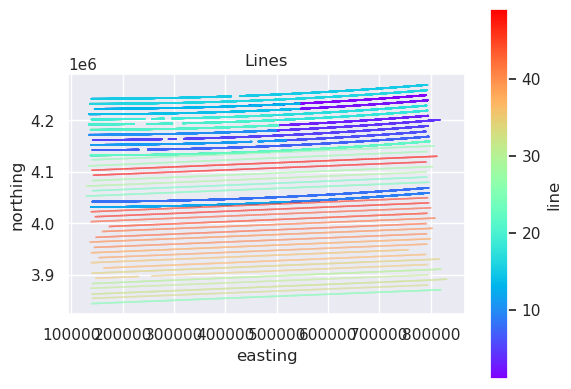

In [6]:
df = data_df[::10]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    title="Lines",
)
ax.set_aspect("equal")

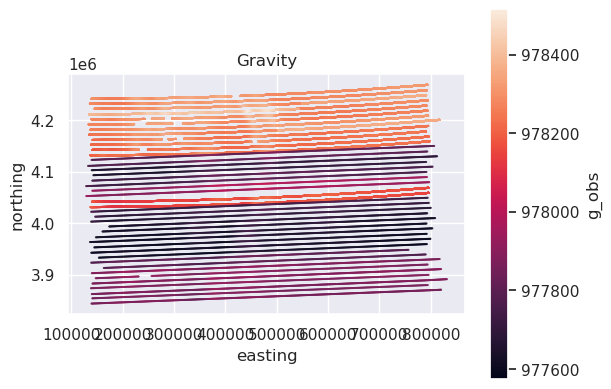

In [7]:
df = data_df[::10]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="g_obs",
    s=0.2,
    title="Gravity",
)
ax.set_aspect("equal")

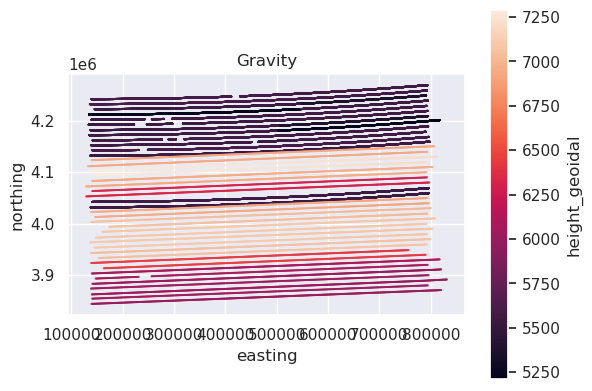

In [8]:
df = data_df[::10]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="height_geoidal",
    s=0.2,
    title="Gravity",
)
ax.set_aspect("equal")